In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Kích thước grid
rows, cols = 4, 4
num_states = rows * cols
terminal_state = (3, 3)  # ô đích, value = 0
gamma = 1.0  # không chiết khấu

# Khởi tạo value function V(s) = 0
V = np.zeros((rows, cols))

# Các hành động: lên, xuống, trái, phải (delta row, delta col)
actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
action_prob = 0.25  # policy đều

def next_state(row, col, action):
    dr, dc = action
    new_r, new_c = row + dr, col + dc
    # Nếu ra ngoài biên thì ở lại ô cũ
    if new_r < 0 or new_r >= rows or new_c < 0 or new_c >= cols:
        return (row, col)
    return (new_r, new_c)

# Iterative policy evaluation
threshold = 1e-4
max_iter = 1000
delta = float('inf')
iter_count = 0

while delta > threshold and iter_count < max_iter:
    delta = 0
    V_new = np.zeros((rows, cols))
    for r in range(rows):
        for c in range(cols):
            if (r, c) == terminal_state:
                continue  # terminal state value always 0
            total = 0
            for a in actions:
                next_r, next_c = next_state(r, c, a)
                reward = -1
                total += action_prob * (reward + gamma * V[next_r, next_c])
            V_new[r, c] = total
            delta = max(delta, abs(V_new[r, c] - V[r, c]))
    V = V_new
    iter_count += 1
    print(f"Iteration {iter_count}, delta = {delta:.6f}")

print("Final value function:")
print(np.round(V, 2))

Iteration 1, delta = 1.000000
Iteration 2, delta = 1.000000
Iteration 3, delta = 1.000000
Iteration 4, delta = 1.000000
Iteration 5, delta = 1.000000
Iteration 6, delta = 1.000000
Iteration 7, delta = 0.995117
Iteration 8, delta = 0.989014
Iteration 9, delta = 0.979370
Iteration 10, delta = 0.968628
Iteration 11, delta = 0.955803
Iteration 12, delta = 0.942261
Iteration 13, delta = 0.927601
Iteration 14, delta = 0.912561
Iteration 15, delta = 0.896987
Iteration 16, delta = 0.881277
Iteration 17, delta = 0.865379
Iteration 18, delta = 0.849507
Iteration 19, delta = 0.833648
Iteration 20, delta = 0.817917
Iteration 21, delta = 0.802316
Iteration 22, delta = 0.786906
Iteration 23, delta = 0.771691
Iteration 24, delta = 0.756703
Iteration 25, delta = 0.741944
Iteration 26, delta = 0.727430
Iteration 27, delta = 0.713163
Iteration 28, delta = 0.699149
Iteration 29, delta = 0.685388
Iteration 30, delta = 0.671880
Iteration 31, delta = 0.658625
Iteration 32, delta = 0.645621
Iteration 33, del

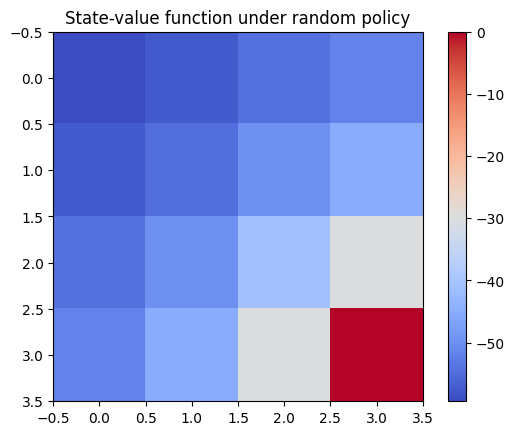

In [2]:
plt.imshow(V, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title('State-value function under random policy')
plt.show()